# Homework 1 - Part 6: Decision Tree Regressor
### Burak Kurucay - 210104004049
---

This section models a decision tree regressor on the Bike Sharing hourly dataset.
The model is evaluated with 6-fold cross validation, and one trained tree is converted into a
set of regression rules.


## Code:

### Import the necessary modules

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, train_test_split
from sklearn.tree import DecisionTreeRegressor, _tree
from sklearn.metrics import mean_absolute_error, r2_score


### Load the dataset
Load the hourly bike sharing dataset and show the number of rows and columns.

In [2]:
data_path = os.path.abspath("../src/data/hour.csv")
df = pd.read_csv(data_path)

print("Dataset shape:", df.shape)
print("Columns:", list(df.columns))


Dataset shape: (17379, 17)
Columns: ['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']


### Sample the dataset
The original dataset is large for repeated tree experiments, so sample 2400 rows while preserving the target distribution by stratifying on binned `cnt` values.

In [3]:
df["cnt_bin"] = pd.qcut(df["cnt"], q=10, duplicates="drop")

df, _ = train_test_split(
    df,
    train_size=3000,
    random_state=42,
    stratify=df["cnt_bin"]
)

df = df.drop(columns=["cnt_bin"]).reset_index(drop=True)

print("Sampled dataset shape:", df.shape)


Sampled dataset shape: (3000, 17)


### Prepare the dataset
Use `cnt` as the regression target. Exclude `casual` and `registered` to avoid target leakage, and drop identifier/date columns.

In [4]:
feature_columns = [
    "season", "yr", "mnth", "hr", "holiday", "weekday", "workingday",
    "weathersit", "temp", "atemp", "hum", "windspeed"
]
target_column = "cnt"

X = df[feature_columns].values
y = df[target_column].values


### Monitor the data
Just to see the dataset loaded.

In [5]:
df[feature_columns + [target_column]].head()


,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,3,0,8,19,0,3,1,1,0.74,0.6818,0.55,0.2985,440
1,2,1,5,19,0,3,1,3,0.50,0.4848,0.77,0.3582,98
2,1,0,3,17,0,6,0,1,0.46,0.4545,0.44,0.3284,213
3,1,1,3,0,0,0,0,1,0.46,0.4545,0.88,0.1940,107
4,3,1,7,2,0,3,1,1,0.64,0.5758,0.89,0.0000,5


### Train By 6-Fold Cross Validation

In [6]:
kf = KFold(n_splits=6, shuffle=True, random_state=42)

fold_results = []
overall_start_time = time.time()

for fold_idx, (train_index, test_index) in enumerate(kf.split(X), start=1):
    X_train, X_test = X[train_index], X[test_index]
    y_train, y_test = y[train_index], y[test_index]

    model = DecisionTreeRegressor(
        criterion="squared_error",
        max_depth=6,
        min_samples_leaf=10,
        random_state=42
    )

    fold_start_time = time.time()
    model.fit(X_train, y_train)
    train_predictions = model.predict(X_train)
    test_predictions = model.predict(X_test)
    fold_end_time = time.time()

    train_rmse = np.sqrt(np.mean((y_train - train_predictions) ** 2))
    test_rmse = np.sqrt(np.mean((y_test - test_predictions) ** 2))

    fold_results.append({
        "fold": fold_idx,
        "train_mae": mean_absolute_error(y_train, train_predictions),
        "test_mae": mean_absolute_error(y_test, test_predictions),
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "train_r2": r2_score(y_train, train_predictions),
        "test_r2": r2_score(y_test, test_predictions),
        "model": model,
        "y_test": y_test,
        "test_predictions": test_predictions,
        "runtime_seconds": fold_end_time - fold_start_time
    })

overall_end_time = time.time()
mean_runtime = np.mean([r["runtime_seconds"] for r in fold_results])
total_runtime = overall_end_time - overall_start_time


## Results:

### Prediction Overview


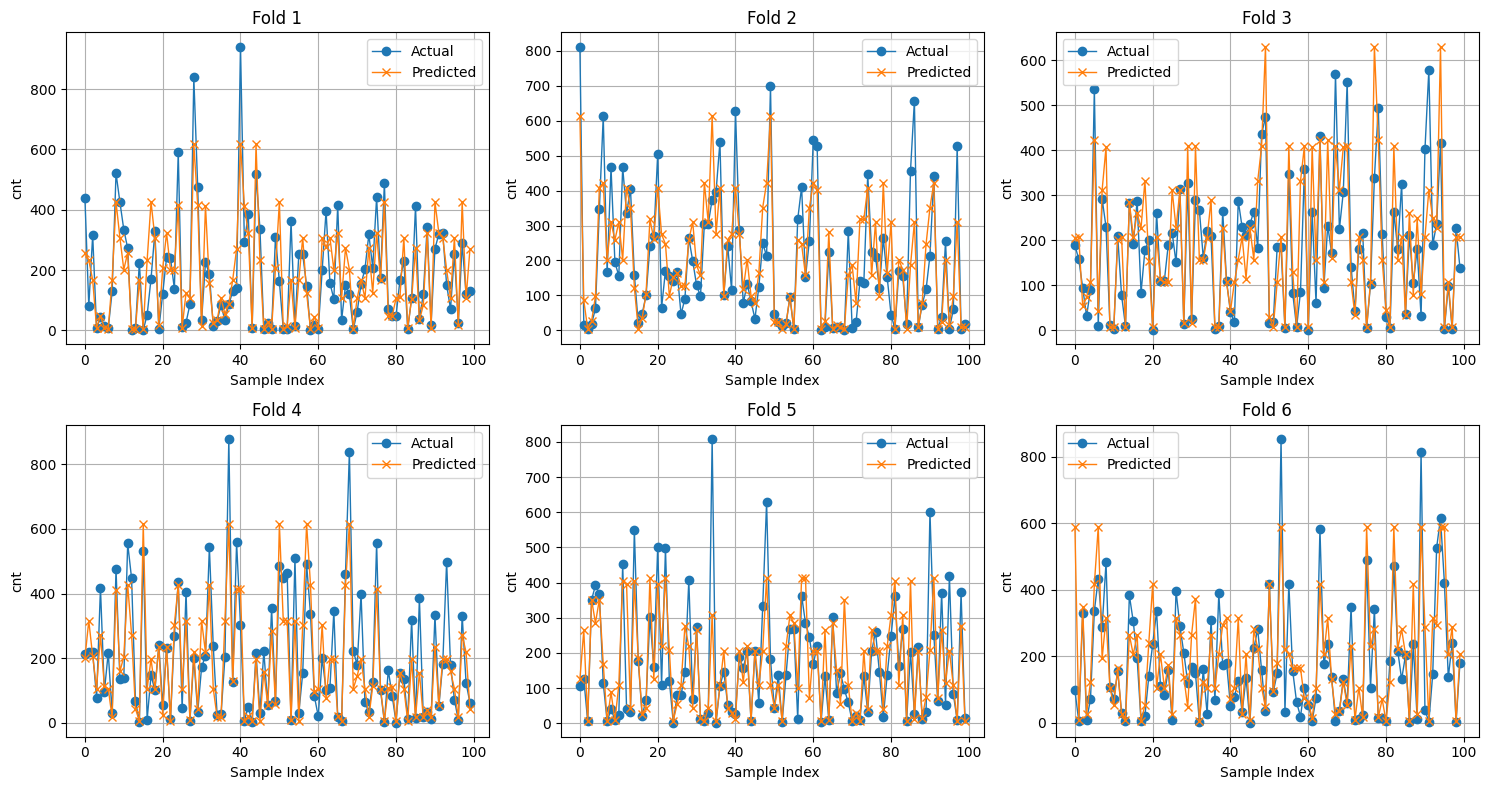

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, result in enumerate(fold_results):
    ax = axes[i]
    y_true = result["y_test"]
    y_pred = result["test_predictions"]

    sample_size = min(100, len(y_true))
    ax.plot(range(sample_size), y_true[:sample_size], marker='o', linewidth=1, label="Actual")
    ax.plot(range(sample_size), y_pred[:sample_size], marker='x', linewidth=1, label="Predicted")
    ax.set_title(f"Fold {result['fold']}")
    ax.set_xlabel("Sample Index")
    ax.set_ylabel("cnt")
    ax.grid(True)
    ax.legend()

plt.tight_layout()
plt.show()


### Regression Metrics

,Fold,Train MAE,Test MAE,Train RMSE,Test RMSE,Train R2,Test R2
0,1,63.1400,67.9071,97.2851,103.2629,0.7111,0.6958
1,2,63.0005,71.0137,96.5903,106.6211,0.7176,0.6631
2,3,63.8613,68.5082,97.4071,104.7004,0.7163,0.6534
3,4,63.5633,63.7430,98.2233,98.9594,0.7087,0.7062
4,5,64.7403,63.8073,99.4986,98.3071,0.6978,0.7246
5,6,63.3687,66.3500,98.4896,99.8384,0.7128,0.6658


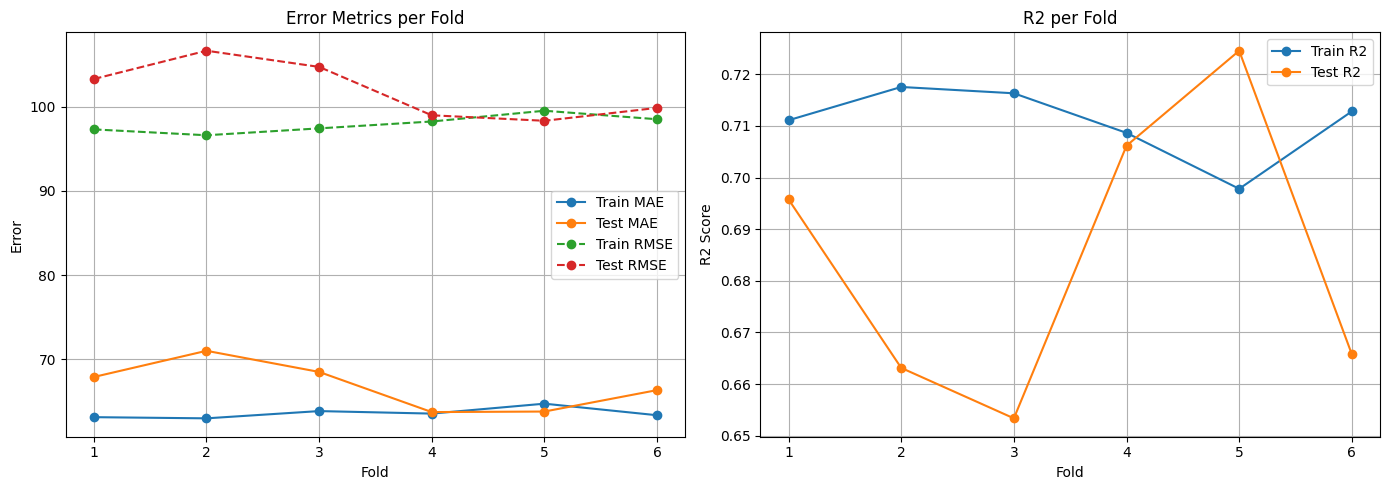

,Metric,Value
0,Mean Train MAE,63.6124
1,Mean Test MAE,66.8882
2,Mean Train RMSE,97.9157
3,Mean Test RMSE,101.9482
4,Mean Train R2,0.7107
5,Mean Test R2,0.6848


In [8]:
metric_rows = []

for result in fold_results:
    metric_rows.append({
        "Fold": result["fold"],
        "Train MAE": result["train_mae"],
        "Test MAE": result["test_mae"],
        "Train RMSE": result["train_rmse"],
        "Test RMSE": result["test_rmse"],
        "Train R2": result["train_r2"],
        "Test R2": result["test_r2"]
    })

df_metrics = pd.DataFrame(metric_rows)
df_metrics.iloc[:, 1:] = df_metrics.iloc[:, 1:].round(4)
display(df_metrics)

folds = [r["fold"] for r in fold_results]
train_maes = [r["train_mae"] for r in fold_results]
test_maes = [r["test_mae"] for r in fold_results]
train_rmses = [r["train_rmse"] for r in fold_results]
test_rmses = [r["test_rmse"] for r in fold_results]
train_r2s = [r["train_r2"] for r in fold_results]
test_r2s = [r["test_r2"] for r in fold_results]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(folds, train_maes, marker="o", label="Train MAE")
axes[0].plot(folds, test_maes, marker="o", label="Test MAE")
axes[0].plot(folds, train_rmses, marker="o", linestyle="--", label="Train RMSE")
axes[0].plot(folds, test_rmses, marker="o", linestyle="--", label="Test RMSE")
axes[0].set_xlabel("Fold")
axes[0].set_ylabel("Error")
axes[0].set_title("Error Metrics per Fold")
axes[0].set_xticks(folds)
axes[0].legend()
axes[0].grid(True)

axes[1].plot(folds, train_r2s, marker="o", label="Train R2")
axes[1].plot(folds, test_r2s, marker="o", label="Test R2")
axes[1].set_xlabel("Fold")
axes[1].set_ylabel("R2 Score")
axes[1].set_title("R2 per Fold")
axes[1].set_xticks(folds)
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

df_metrics_summary = pd.DataFrame({
    "Metric": [
        "Mean Train MAE",
        "Mean Test MAE",
        "Mean Train RMSE",
        "Mean Test RMSE",
        "Mean Train R2",
        "Mean Test R2"
    ],
    "Value": [
        df_metrics["Train MAE"].mean(),
        df_metrics["Test MAE"].mean(),
        df_metrics["Train RMSE"].mean(),
        df_metrics["Test RMSE"].mean(),
        df_metrics["Train R2"].mean(),
        df_metrics["Test R2"].mean()
    ]
})

df_metrics_summary["Value"] = df_metrics_summary["Value"].round(4)
display(df_metrics_summary)


### Runtime Performance

In [9]:
runtime_rows = []

for result in fold_results:
    runtime_rows.append({
        "Fold": result["fold"],
        "Runtime (seconds)": result["runtime_seconds"]
    })

df_runtime = pd.DataFrame(runtime_rows)
df_runtime["Runtime (seconds)"] = df_runtime["Runtime (seconds)"].round(4)
display(df_runtime)

df_runtime_summary = pd.DataFrame({
    "Metric": [
        "Average runtime per fold",
        "Total 6-fold CV runtime"
    ],
    "Runtime (seconds)": [
        mean_runtime,
        total_runtime
    ]
})

df_runtime_summary["Runtime (seconds)"] = df_runtime_summary["Runtime (seconds)"].round(4)
display(df_runtime_summary)


,Fold,Runtime (seconds)
0,1,0.0052
1,2,0.0032
2,3,0.0031
3,4,0.0032
4,5,0.0033
5,6,0.0033


,Metric,Runtime (seconds)
0,Average runtime per fold,0.0036
1,Total 6-fold CV runtime,0.0256


### Selected Fold Performance Results
Select the fold whose test RMSE is closest to the mean test RMSE across all folds.

In [10]:
mean_test_rmse = np.mean([r["test_rmse"] for r in fold_results])

selected_fold = min(
    fold_results,
    key=lambda r: abs(r["test_rmse"] - mean_test_rmse)
)


,Metric,Value
0,Train MAE,63.1400
1,Test MAE,67.9071
2,Train RMSE,97.2851
3,Test RMSE,103.2629
4,Train R2,0.7111
5,Test R2,0.6958


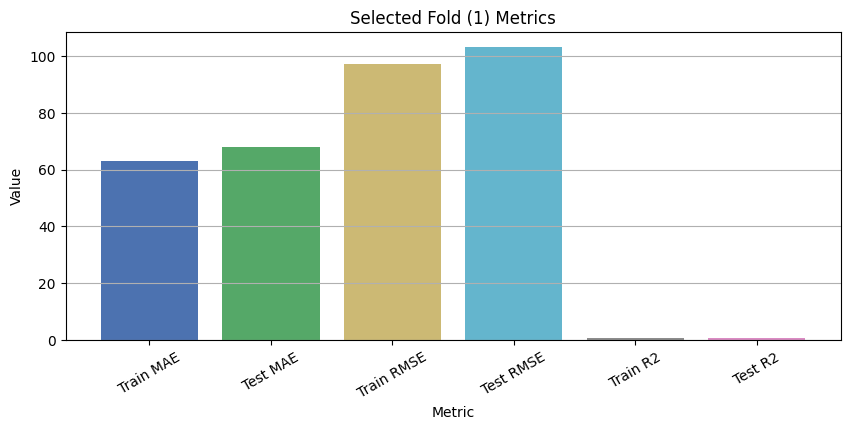

,Actual,Predicted
0,440,257.0260
1,80,231.9294
2,316,166.8812
3,7,9.1270
4,43,47.7222
5,14,9.1270
6,7,5.1399
7,129,166.8812
8,521,425.5270
9,425,307.1731


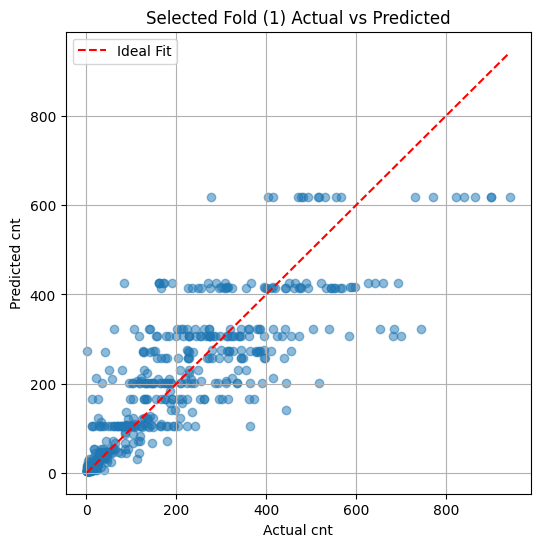

In [11]:
df_selected_performance = pd.DataFrame({
    "Metric": ["Train MAE", "Test MAE", "Train RMSE", "Test RMSE", "Train R2", "Test R2"],
    "Value": [
        selected_fold["train_mae"],
        selected_fold["test_mae"],
        selected_fold["train_rmse"],
        selected_fold["test_rmse"],
        selected_fold["train_r2"],
        selected_fold["test_r2"]
    ]
})

df_selected_performance["Value"] = df_selected_performance["Value"].round(4)
display(df_selected_performance)

plt.figure(figsize=(10, 4))
plt.bar(
    df_selected_performance["Metric"],
    df_selected_performance["Value"],
    color=["#4C72B0", "#55A868", "#CCB974", "#64B5CD", "#8C8C8C", "#DA8BC3"]
)
plt.xlabel("Metric")
plt.ylabel("Value")
plt.title(f"Selected Fold ({selected_fold['fold']}) Metrics")
plt.xticks(rotation=30)
plt.grid(axis="y")
plt.show()

selected_predictions_df = pd.DataFrame({
    "Actual": selected_fold["y_test"][:20],
    "Predicted": np.round(selected_fold["test_predictions"][:20], 4)
})

display(selected_predictions_df)

plt.figure(figsize=(6, 6))
plt.scatter(selected_fold["y_test"], selected_fold["test_predictions"], alpha=0.5)
min_val = min(selected_fold["y_test"].min(), selected_fold["test_predictions"].min())
max_val = max(selected_fold["y_test"].max(), selected_fold["test_predictions"].max())
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--", label="Ideal Fit")
plt.xlabel("Actual cnt")
plt.ylabel("Predicted cnt")
plt.title(f"Selected Fold ({selected_fold['fold']}) Actual vs Predicted")
plt.legend()
plt.grid(True)
plt.show()


### Extract the Path to Each Leaf Node

In [12]:
def tree_regressor_leaf_paths(model, feature_names):
    tree = model.tree_
    leaf_paths = []

    def walk(node_id, conditions, visited_nodes):
        if tree.feature[node_id] != _tree.TREE_UNDEFINED:
            feature_name = feature_names[tree.feature[node_id]]
            threshold = tree.threshold[node_id]

            walk(
                tree.children_left[node_id],
                conditions + [f"{feature_name} <= {threshold:.4f}"],
                visited_nodes + [node_id]
            )
            walk(
                tree.children_right[node_id],
                conditions + [f"{feature_name} > {threshold:.4f}"],
                visited_nodes + [node_id]
            )
        else:
            prediction = float(tree.value[node_id][0][0])
            samples = int(tree.n_node_samples[node_id])
            leaf_paths.append({
                "Leaf Node": node_id,
                "Visited Nodes": " -> ".join(map(str, visited_nodes + [node_id])),
                "Path": "IF " + " AND ".join(conditions),
                "Prediction": round(prediction, 4),
                "Samples": samples
            })

    walk(0, [], [])
    return leaf_paths


leaf_paths = tree_regressor_leaf_paths(selected_fold["model"], feature_columns)

pd.set_option("display.max_colwidth", None)

df_leaf_paths = pd.DataFrame(leaf_paths)

display(
    df_leaf_paths.style.set_properties(**{
        "white-space": "pre-wrap",
        "text-align": "left"
    })
)


,Leaf Node,Visited Nodes,Path,Prediction,Samples
0,6,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 6,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday <= 0.5000 AND yr <= 0.5000 AND atemp <= 0.4773,32.478300,23
1,7,0 -> 1 -> 2 -> 3 -> 4 -> 5 -> 7,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday <= 0.5000 AND yr <= 0.5000 AND atemp > 0.4773,83.300000,10
2,9,0 -> 1 -> 2 -> 3 -> 4 -> 8 -> 9,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday <= 0.5000 AND yr > 0.5000 AND atemp <= 0.4697,91.928600,14
3,10,0 -> 1 -> 2 -> 3 -> 4 -> 8 -> 10,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday <= 0.5000 AND yr > 0.5000 AND atemp > 0.4697,127.444400,18
4,13,0 -> 1 -> 2 -> 3 -> 11 -> 12 -> 13,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday > 0.5000 AND hr <= 0.5000 AND temp <= 0.4500,24.424200,33
5,14,0 -> 1 -> 2 -> 3 -> 11 -> 12 -> 14,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday > 0.5000 AND hr <= 0.5000 AND temp > 0.4500,47.722200,36
6,16,0 -> 1 -> 2 -> 3 -> 11 -> 15 -> 16,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday > 0.5000 AND hr > 0.5000 AND weekday <= 4.5000,14.234000,47
7,17,0 -> 1 -> 2 -> 3 -> 11 -> 15 -> 17,IF hr <= 6.5000 AND hr <= 5.5000 AND hr <= 1.5000 AND workingday > 0.5000 AND hr > 0.5000 AND weekday > 4.5000,30.600000,15
8,21,0 -> 1 -> 2 -> 18 -> 19 -> 20 -> 21,IF hr <= 6.5000 AND hr <= 5.5000 AND hr > 1.5000 AND workingday <= 0.5000 AND hr <= 2.5000 AND atemp <= 0.3257,33.583300,12
9,22,0 -> 1 -> 2 -> 18 -> 19 -> 20 -> 22,IF hr <= 6.5000 AND hr <= 5.5000 AND hr > 1.5000 AND workingday <= 0.5000 AND hr <= 2.5000 AND atemp > 0.3257,68.608700,23


## Comments:
- The decision tree regressor provides a clear improvement over the linear SVR and reaches a moderate-to-strong level of predictive performance. Test R2 is around 0.68 on average, and both test MAE and test RMSE are substantially lower than those of the linear model.
- The train and test metrics are relatively close, which suggests that the chosen tree depth controls overfitting reasonably well. The model benefits from nonlinear partitioning of the feature space, but it does not appear to memorize the training set excessively.
- Compared with KNN, the tree gives weaker results, yet it still captures local structure better than a global linear regressor. This is expected because tree-based splits can represent threshold-type relationships in variables such as hour, season, and weather.
- The prediction overview shows that the tree can follow changes in the target more flexibly than the linear SVR, although some deviations remain in folds with more complex demand patterns. This reflects the piecewise-constant nature of tree predictions.
- The horizontal bands in the actual-versus-predicted scatter plot are also a natural consequence of the decision tree structure. Samples that fall into the same terminal leaf receive the same constant prediction, so repeated leaf values appear as stacked horizontal levels in the graph.
- A further advantage of this model is interpretability. The extracted root-to-leaf paths make it possible to connect numerical performance with explicit decision rules, which is useful in a research-style discussion of the model.
